# LP Quality & Relevance 评估分析 (0306)

**数据来源（random 1K 批次，3人标注）：**
- **Quality**：`UHRS_Task_lp_labeling_0306_random1K_Quality.tsv`
- **Relevance**：`UHRS_Task_lp_labeling_0306_random1K_Relevance.tsv`

**分析目标：**
1. Quality：按 ImgUrl 多数投票 → FinalLabel，统计各维度 Bad Rate
2. Relevance：按 ImgUrl 多数投票 → RelevanceLabel，统计 Good/Fair/Bad 分布
3. 联合分析：Quality × Relevance 交叉分布
4. 可选：下载各类别图片到本地

---
## 1. 公共配置 & 工具函数

In [27]:
import pandas as pd
import os
import requests
import re
from pathlib import Path
from collections import Counter

# ================= 文件路径 =================
input_quality   = r"D:\Data\T2I\AutoGenValidation\UHRS_Task_lp_labeling_0306_random1K_Quality.tsv"
input_relevance = r"D:\Data\T2I\AutoGenValidation\UHRS_Task_lp_labeling_0306_random1K_Relevance.tsv"

# ================= 下载目录 =================
save_dir_base = r"D:\Data\T2I\AutoGenValidation\label_results_0306"

# ================= Quality 维度列表 =================
quality_dimensions = [
    'TextLogoClarity',
    'RealisticPhysicallyPlausible',
    'BrightnessContrastColorSaturation',
    'Imageclarity',
    'SubjectClarity',
    'CompositionLayout',
]

# ================= 工具函数 =================
def majority_vote(series, threshold=2):
    """
    多数投票：统计各标签票数，返回得票最多的标签。
    若 Bad 票数 >= threshold，优先判定为 Bad（与旧逻辑兼容）。
    """
    counts = Counter(series)
    if counts.get('Bad', 0) >= threshold:
        return 'Bad'
    return counts.most_common(1)[0][0]


def vote_quality(df):
    """
    Quality 投票聚合：
      - FinalDecision: Bad 票数 >= 2 → 'Bad'，否则取多数票
      - 各维度同理
      - 返回每个 ImgUrl 一行的 DataFrame
    """
    df = df.copy()
    df['ImgUrl'] = df['ImgUrl'].astype(str).str.strip()
    df['FinalDecision'] = df['FinalDecision'].astype(str).str.strip()

    for dim in quality_dimensions:
        if dim in df.columns:
            df[dim] = df[dim].astype(str).str.strip()

    # 投票聚合
    grouped = df.groupby('ImgUrl')

    records = []
    for img_url, grp in grouped:
        row = {'ImgUrl': img_url, 'n_judges': len(grp)}
        # FinalDecision 投票
        row['FinalLabel'] = majority_vote(grp['FinalDecision'])
        row['Bad_votes'] = (grp['FinalDecision'] == 'Bad').sum()
        row['Fair_votes'] = (grp['FinalDecision'] == 'Fair').sum()
        row['Good_votes'] = (grp['FinalDecision'] == 'Good').sum()
        # 各维度投票
        for dim in quality_dimensions:
            if dim in grp.columns:
                row[f'{dim}_label'] = majority_vote(grp[dim])
                row[f'{dim}_bad_votes'] = (grp[dim] == 'Bad').sum()
            else:
                row[f'{dim}_label'] = 'GoodOrN/A'
                row[f'{dim}_bad_votes'] = 0
        # lp_id（取第一个）
        if 'lp_id' in grp.columns:
            row['lp_id'] = grp['lp_id'].iloc[0]
        records.append(row)

    return pd.DataFrame(records)


def vote_relevance(df):
    """
    Relevance 投票聚合：
      - Rating: Bad 票数 >= 2 → 'Bad'，否则取多数票
      - 返回每个 ImgUrl 一行的 DataFrame
    """
    df = df.copy()
    df['ImgUrl'] = df['ImgUrl'].astype(str).str.strip()
    df['Rating'] = df['Rating'].astype(str).str.strip()

    records = []
    for img_url, grp in df.groupby('ImgUrl'):
        row = {'ImgUrl': img_url, 'n_judges': len(grp)}
        row['RelevanceLabel'] = majority_vote(grp['Rating'])
        row['Rel_Bad_votes']  = (grp['Rating'] == 'Bad').sum()
        row['Rel_Fair_votes'] = (grp['Rating'] == 'Fair').sum()
        row['Rel_Good_votes'] = (grp['Rating'] == 'Good').sum()
        # 收集非 N/A 的评论
        if 'Comment' in grp.columns:
            comments = grp['Comment'].dropna().astype(str)
            comments = [c for c in comments if c.strip().lower() != 'n/a' and c.strip() != '']
            row['Comments'] = ' | '.join(comments) if comments else 'N/A'
        if 'lp_id' in grp.columns:
            row['lp_id'] = grp['lp_id'].iloc[0]
        records.append(row)

    return pd.DataFrame(records)


def download_images(url_list, save_dir, label=''):
    """下载图片列表到 save_dir，跳过已存在的"""
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    ok, fail = 0, 0
    for url in url_list:
        filename = url.split('/')[-1].split('?')[0] or 'image'
        save_path = os.path.join(save_dir, filename)
        if os.path.exists(save_path):
            ok += 1
            continue
        try:
            r = requests.get(url, timeout=15)
            if r.status_code == 200:
                with open(save_path, 'wb') as f:
                    f.write(r.content)
                ok += 1
            else:
                fail += 1
        except Exception:
            fail += 1
    print(f"  [{label}] 成功: {ok}, 失败: {fail}, 目录: {save_dir}")


print("配置完成")

配置完成


---
## 2. Quality 标注 — 读取 & 投票

In [28]:
df_q_raw = pd.read_csv(input_quality, sep='\t', header=0)
print(f"Quality 原始数据: {len(df_q_raw)} 条")
print(f"列名: {df_q_raw.columns.tolist()}")
df_q_raw.head(3)

Quality 原始数据: 15000 条
列名: ['JudgeID', 'HitGroupDataInt', 'HitDataInt', 'HitState', 'HitType', 'Price', 'JudgmentState', 'JudgmentDataInt', 'JudgmentDataIntName', 'JudgmentSubmitTime', 'JudgmentTypeID', 'JudgmentType', 'Consensus', 'TimeSpentOnJudgment', 'HitGroupID', 'HitID', 'lp_id', 'ImageSource', 'FinalUrl', 'ImgUrl', 'JudgmentID', 'OtherComment', 'FinalDecision', 'Imageclarity', 'BrightnessContrastColorSaturation', 'SubjectClarity', 'TextLogoClarity', 'CompositionLayout', 'RealisticPhysicallyPlausible', 'MainSubjectClarityBadOpotion']


,JudgeID,HitGroupDataInt,HitDataInt,HitState,HitType,Price,JudgmentState,JudgmentDataInt,JudgmentDataIntName,JudgmentSubmitTime,...,JudgmentID,OtherComment,FinalDecision,Imageclarity,BrightnessContrastColorSaturation,SubjectClarity,TextLogoClarity,CompositionLayout,RealisticPhysicallyPlausible,MainSubjectClarityBadOpotion
0,1628038,-1,-1,0,Normal,NaN,2,0,NaN,3/8/2026 7:45:40 PM,...,1306945351,NaN,Fair,Good,Good,GoodOrN/A,Fair,Good,GoodOrN/A,NaN
1,1628038,-1,-1,0,Normal,NaN,2,0,NaN,3/8/2026 7:47:21 PM,...,1306946039,NaN,Fair,Fair,Good,GoodOrN/A,GoodOrN/A,Good,GoodOrN/A,NaN
2,1628038,-1,-1,0,Normal,NaN,2,0,NaN,3/8/2026 7:49:36 PM,...,1306944648,NaN,Bad,Good,Good,GoodOrN/A,GoodOrN/A,Good,Bad,NaN


In [29]:
# 标注人分布
print("Quality 标注人（JudgeID）分布:")
print(df_q_raw['JudgeID'].value_counts().to_string())
print(f"\n每张图平均标注人数: {len(df_q_raw) / df_q_raw['ImgUrl'].nunique():.1f}")
print(f"FinalDecision 取值分布:")
print(df_q_raw['FinalDecision'].value_counts().to_string())

Quality 标注人（JudgeID）分布:
JudgeID
1628038    1484
3493566    1441
1307792    1384
906828     1340
1126533    1175
3493592    1114
3496655    1066
3493564    1044
1086551     863
3493593     768
1038785     720
973048      614
3496659     554
505804      470
1856447     343
3493570     293
3493569     207
577223      120

每张图平均标注人数: 3.0
FinalDecision 取值分布:
FinalDecision
Good             7965
Bad              4671
Fair             2255
Imageloadfail      98
Logo               11


In [30]:
voted_q = vote_quality(df_q_raw)

n_total = len(voted_q)
n_bad   = (voted_q['FinalLabel'] == 'Bad').sum()
n_fair  = (voted_q['FinalLabel'] == 'Fair').sum()
n_good  = (voted_q['FinalLabel'] == 'Good').sum()

print(f"=== Quality 投票结果（0306）===")
print(f"唯一 URL 总数 : {n_total}")
print(f"  Good   : {n_good:5d}  ({n_good/n_total*100:.1f}%)")
print(f"  Fair   : {n_fair:5d}  ({n_fair/n_total*100:.1f}%)")
print(f"  Bad    : {n_bad:5d}  ({n_bad/n_total*100:.1f}%)")
print()
print("各维度 Bad Rate:")
for dim in quality_dimensions:
    col = f'{dim}_label'
    if col in voted_q.columns:
        n = (voted_q[col] == 'Bad').sum()
        print(f"  {dim:<40s}: {n:4d}/{n_total}  ({n/n_total*100:.1f}%)")

voted_q.head()

=== Quality 投票结果（0306）===
唯一 URL 总数 : 5000
  Good   :  2952  (59.0%)
  Fair   :   562  (11.2%)
  Bad    :  1473  (29.5%)

各维度 Bad Rate:
  TextLogoClarity                         :   82/5000  (1.6%)
  RealisticPhysicallyPlausible            :  831/5000  (16.6%)
  BrightnessContrastColorSaturation       :    0/5000  (0.0%)
  Imageclarity                            :    8/5000  (0.2%)
  SubjectClarity                          :  210/5000  (4.2%)
  CompositionLayout                       :  133/5000  (2.7%)


,ImgUrl,n_judges,FinalLabel,Bad_votes,Fair_votes,Good_votes,TextLogoClarity_label,TextLogoClarity_bad_votes,RealisticPhysicallyPlausible_label,RealisticPhysicallyPlausible_bad_votes,BrightnessContrastColorSaturation_label,BrightnessContrastColorSaturation_bad_votes,Imageclarity_label,Imageclarity_bad_votes,SubjectClarity_label,SubjectClarity_bad_votes,CompositionLayout_label,CompositionLayout_bad_votes,lp_id
0,https://unitorchazureblob.blob.core.windows.ne...,3,Bad,2,1,0,GoodOrN/A,0,GoodOrN/A,1,Good,0,Good,0,Fair,1,Good,0,Random1000_1000_Prompt1_1344x768.jpg
1,https://unitorchazureblob.blob.core.windows.ne...,3,Good,0,1,2,GoodOrN/A,0,GoodOrN/A,0,Good,0,Good,0,GoodOrN/A,0,Good,0,Random1000_1000_Prompt2_1344x768.jpg
2,https://unitorchazureblob.blob.core.windows.ne...,3,Bad,2,1,0,GoodOrN/A,1,Bad,2,Good,0,Good,0,GoodOrN/A,0,Good,0,Random1000_1000_Prompt3_1344x768.jpg
3,https://unitorchazureblob.blob.core.windows.ne...,3,Good,1,0,2,GoodOrN/A,0,GoodOrN/A,1,Good,0,Good,0,GoodOrN/A,0,Good,0,Random1000_1000_Prompt4_1344x768.jpg
4,https://unitorchazureblob.blob.core.windows.ne...,3,Good,1,0,2,GoodOrN/A,0,GoodOrN/A,0,Good,0,Good,0,GoodOrN/A,1,Good,1,Random1000_1000_Prompt5_1344x768.jpg


C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\1308406569.py:37: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\1308406569.py:37: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\1308406569.py:37: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\1308406569.py:37: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\1308406569.py:37: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\130840656

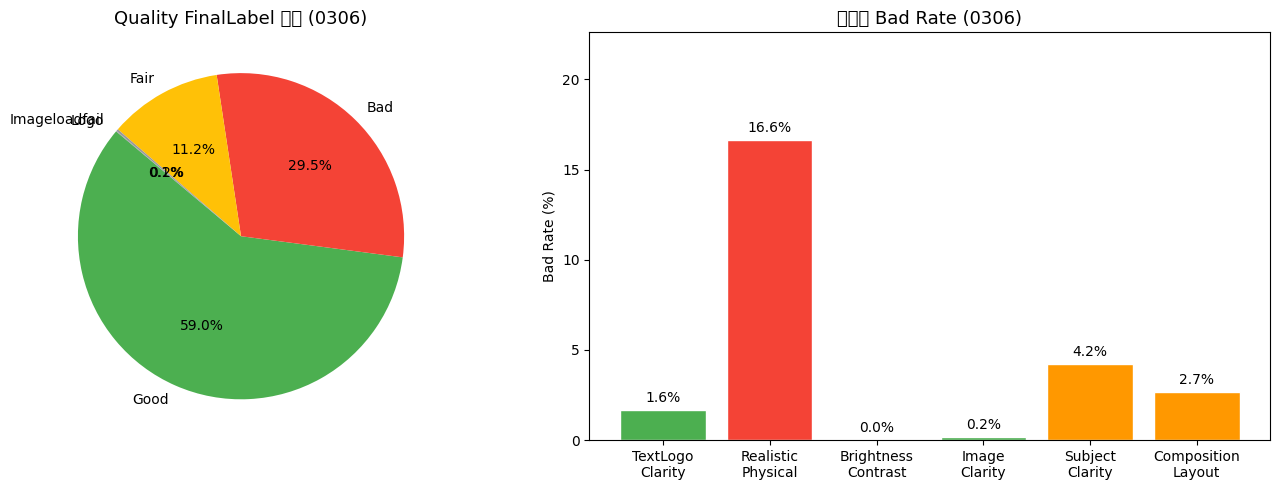

图表已保存


In [31]:
import matplotlib.pyplot as plt

# --- FinalLabel 饼图 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts = voted_q['FinalLabel'].value_counts()
colors_map = {'Good': '#4CAF50', 'Fair': '#FFC107', 'Bad': '#F44336'}
pie_colors = [colors_map.get(l, '#999') for l in label_counts.index]
axes[0].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=pie_colors, startangle=140)
axes[0].set_title('Quality FinalLabel 分布 (0306)', fontsize=13)

# --- 各维度 Bad Rate 条形图 ---
dim_bad_rates = []
for dim in quality_dimensions:
    col = f'{dim}_label'
    rate = (voted_q[col] == 'Bad').sum() / n_total * 100 if col in voted_q.columns else 0
    dim_bad_rates.append(rate)

short_names = [
    'TextLogo\nClarity',
    'Realistic\nPhysical',
    'Brightness\nContrast',
    'Image\nClarity',
    'Subject\nClarity',
    'Composition\nLayout',
]
bar_colors = ['#F44336' if r > 5 else '#FF9800' if r > 2 else '#4CAF50' for r in dim_bad_rates]
bars = axes[1].bar(short_names, dim_bad_rates, color=bar_colors, edgecolor='white')
axes[1].set_title('各维度 Bad Rate (0306)', fontsize=13)
axes[1].set_ylabel('Bad Rate (%)')
axes[1].set_ylim(0, max(dim_bad_rates) * 1.3 + 1)
for bar, rate in zip(bars, dim_bad_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{rate:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(save_dir_base, 'quality_overview_0306.png'), dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存")

---
## 3. Relevance 标注 — 读取 & 投票

In [32]:
df_r_raw = pd.read_csv(input_relevance, sep='\t', header=0)
print(f"Relevance 原始数据: {len(df_r_raw)} 条")
print(f"列名: {df_r_raw.columns.tolist()}")
df_r_raw.head(3)

Relevance 原始数据: 15000 条
列名: ['JudgeID', 'HitGroupDataInt', 'HitDataInt', 'HitState', 'HitType', 'Price', 'JudgmentState', 'JudgmentDataInt', 'JudgmentDataIntName', 'JudgmentSubmitTime', 'JudgmentTypeID', 'JudgmentType', 'Consensus', 'TimeSpentOnJudgment', 'HitGroupID', 'HitID', 'lp_id', 'ImageSource', 'FinalUrl', 'ImgUrl', 'JudgmentID', 'Rating', 'Comment']


,JudgeID,HitGroupDataInt,HitDataInt,HitState,HitType,Price,JudgmentState,JudgmentDataInt,JudgmentDataIntName,JudgmentSubmitTime,...,TimeSpentOnJudgment,HitGroupID,HitID,lp_id,ImageSource,FinalUrl,ImgUrl,JudgmentID,Rating,Comment
0,2782231,-1,-1,0,Normal,NaN,2,1002,Good,3/8/2026 8:35:38 PM,...,124033,208536856,398880985,Random1000_620_Prompt2_1344x768.jpg,AdsT2Iv3,https://www.soggyyard.com/,https://unitorchazureblob.blob.core.windows.ne...,1004623838,Good,NaN
1,2782231,-1,-1,0,Normal,NaN,2,1002,Good,3/8/2026 8:37:04 PM,...,85992,208536869,398880998,Random1000_725_Prompt2_1344x768.jpg,AdsT2Iv3,https://choose.kaiserpermanente.org/fehb/plans,https://unitorchazureblob.blob.core.windows.ne...,1004623878,Good,NaN
2,2782231,-1,-1,0,Normal,NaN,2,1003,Fair,3/8/2026 8:42:58 PM,...,79996,208537008,398881137,Random1000_617_Prompt3_1344x768.jpg,AdsT2Iv3,https://www.dailyom.com/?aff=101&utm_source=bi...,https://unitorchazureblob.blob.core.windows.ne...,1004624294,Fair,"The image depicts a person working at a desk, ..."


In [33]:
# 标注人分布
print("Relevance 标注人（JudgeID）分布:")
print(df_r_raw['JudgeID'].value_counts().to_string())
print(f"\n每张图平均标注人数: {len(df_r_raw) / df_r_raw['ImgUrl'].nunique():.1f}")
print(f"\nRating 取值分布:")
print(df_r_raw['Rating'].value_counts().to_string())

Relevance 标注人（JudgeID）分布:
JudgeID
555975     4444
868737     2562
906828     2354
425073     1270
1027019     923
449511      685
422897      574
577223      428
2669883     409
418749      295
431464      295
746755      272
259857      249
487716      147
379188       40
2782231      22
435612       15
572065       13
396608        3

每张图平均标注人数: 3.0

Rating 取值分布:
Rating
Good               9323
Fair               3417
Bad                1866
PageDoesNotLoad     394


In [34]:
voted_r = vote_relevance(df_r_raw)

n_total_r  = len(voted_r)
n_bad_r    = (voted_r['RelevanceLabel'] == 'Bad').sum()
n_fair_r   = (voted_r['RelevanceLabel'] == 'Fair').sum()
n_good_r   = (voted_r['RelevanceLabel'] == 'Good').sum()

print(f"=== Relevance 投票结果（0306）===")
print(f"唯一 URL 总数 : {n_total_r}")
print(f"  Good   : {n_good_r:5d}  ({n_good_r/n_total_r*100:.1f}%)")
print(f"  Fair   : {n_fair_r:5d}  ({n_fair_r/n_total_r*100:.1f}%)")
print(f"  Bad    : {n_bad_r:5d}  ({n_bad_r/n_total_r*100:.1f}%)")

voted_r.head()

=== Relevance 投票结果（0306）===
唯一 URL 总数 : 5000
  Good   :  3421  (68.4%)
  Fair   :  1019  (20.4%)
  Bad    :   462  (9.2%)


,ImgUrl,n_judges,RelevanceLabel,Rel_Bad_votes,Rel_Fair_votes,Rel_Good_votes,Comments,lp_id
0,https://unitorchazureblob.blob.core.windows.ne...,3,Fair,0,3,0,N/A,Random1000_1000_Prompt1_1344x768.jpg
1,https://unitorchazureblob.blob.core.windows.ne...,3,Bad,2,0,1,N/A,Random1000_1000_Prompt2_1344x768.jpg
2,https://unitorchazureblob.blob.core.windows.ne...,3,Fair,1,1,1,N/A,Random1000_1000_Prompt3_1344x768.jpg
3,https://unitorchazureblob.blob.core.windows.ne...,3,Fair,1,2,0,The image is only somewhat related to the to t...,Random1000_1000_Prompt4_1344x768.jpg
4,https://unitorchazureblob.blob.core.windows.ne...,3,Fair,1,1,1,N/A,Random1000_1000_Prompt5_1344x768.jpg


C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\3965756647.py:8: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\3965756647.py:8: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\3965756647.py:9: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(save_dir_base, 'relevance_overview_0306.png'), dpi=150, bbox_inches='tight')
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\3965756647.py:9: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(save_dir_base, 'relevance_overview_0306.png'), dpi=150, bbox_inches='tight')
C:\Users\jinjinchen\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools

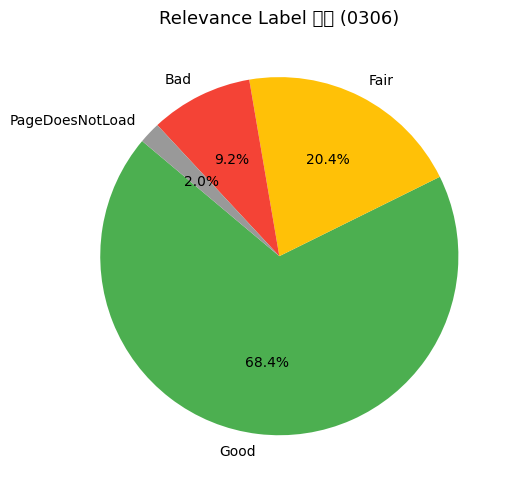

图表已保存


In [35]:
# Relevance 分布饼图
fig, ax = plt.subplots(figsize=(6, 5))
rel_counts = voted_r['RelevanceLabel'].value_counts()
pie_colors = [colors_map.get(l, '#999') for l in rel_counts.index]
ax.pie(rel_counts.values, labels=rel_counts.index, autopct='%1.1f%%',
       colors=pie_colors, startangle=140)
ax.set_title('Relevance Label 分布 (0306)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(save_dir_base, 'relevance_overview_0306.png'), dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存")

In [36]:
# 查看 Bad/Fair 的评论样例
print("=== Relevance Bad 样例评论 ===")
bad_comments = voted_r[voted_r['RelevanceLabel'] == 'Bad'][['lp_id', 'RelevanceLabel', 'Comments']].head(10)
for _, row in bad_comments.iterrows():
    print(f"  [{row['lp_id']}] {row['Comments'][:120]}")
print()
print("=== Relevance Fair 样例评论 ===")
fair_comments = voted_r[voted_r['RelevanceLabel'] == 'Fair'][['lp_id', 'RelevanceLabel', 'Comments']].head(10)
for _, row in fair_comments.iterrows():
    print(f"  [{row['lp_id']}] {row['Comments'][:120]}")

=== Relevance Bad 样例评论 ===
  [Random1000_1000_Prompt2_1344x768.jpg] N/A
  [Random1000_102_Prompt2_1344x768.jpg] N/A
  [Random1000_102_Prompt4_1344x768.jpg] N/A
  [Random1000_104_Prompt3_1344x768.jpg] N/A
  [Random1000_10_Prompt2_1344x768.jpg] N/A
  [Random1000_111_Prompt1_1344x768.jpg] N/A
  [Random1000_118_Prompt3_1344x768.jpg] This looks like a wall stability bar which would be good but not on the floor. 
  [Random1000_124_Prompt1_1344x768.jpg] N/A
  [Random1000_124_Prompt4_1344x768.jpg] N/A
  [Random1000_125_Prompt2_1344x768.jpg] The LP is about whiskey and it's recognizable that the drink shown in the image is not whiskey, a mismatch.

=== Relevance Fair 样例评论 ===
  [Random1000_1000_Prompt1_1344x768.jpg] N/A
  [Random1000_1000_Prompt3_1344x768.jpg] N/A
  [Random1000_1000_Prompt4_1344x768.jpg] The image is only somewhat related to the to the LP
  [Random1000_1000_Prompt5_1344x768.jpg] N/A
  [Random1000_101_Prompt2_1344x768.jpg] N/A
  [Random1000_102_Prompt1_1344x768.jpg] N/A
  [Rando

---
## 4. 联合分析：Quality × Relevance

In [37]:
# 通过 ImgUrl 合并两份投票结果
merged = pd.merge(
    voted_q[['ImgUrl', 'lp_id', 'FinalLabel', 'Bad_votes', 'Fair_votes', 'Good_votes']
            + [f'{d}_label' for d in quality_dimensions]],
    voted_r[['ImgUrl', 'RelevanceLabel', 'Rel_Bad_votes', 'Rel_Fair_votes', 'Rel_Good_votes', 'Comments']],
    on='ImgUrl', how='inner'
)

print(f"Quality 唯一 URL: {len(voted_q)}")
print(f"Relevance 唯一 URL: {len(voted_r)}")
print(f"合并后（inner join）: {len(merged)} 条")
merged.head(3)

Quality 唯一 URL: 5000
Relevance 唯一 URL: 5000
合并后（inner join）: 5000 条


,ImgUrl,lp_id,FinalLabel,Bad_votes,Fair_votes,Good_votes,TextLogoClarity_label,RealisticPhysicallyPlausible_label,BrightnessContrastColorSaturation_label,Imageclarity_label,SubjectClarity_label,CompositionLayout_label,RelevanceLabel,Rel_Bad_votes,Rel_Fair_votes,Rel_Good_votes,Comments
0,https://unitorchazureblob.blob.core.windows.ne...,Random1000_1000_Prompt1_1344x768.jpg,Bad,2,1,0,GoodOrN/A,GoodOrN/A,Good,Good,Fair,Good,Fair,0,3,0,N/A
1,https://unitorchazureblob.blob.core.windows.ne...,Random1000_1000_Prompt2_1344x768.jpg,Good,0,1,2,GoodOrN/A,GoodOrN/A,Good,Good,GoodOrN/A,Good,Bad,2,0,1,N/A
2,https://unitorchazureblob.blob.core.windows.ne...,Random1000_1000_Prompt3_1344x768.jpg,Bad,2,1,0,GoodOrN/A,Bad,Good,Good,GoodOrN/A,Good,Fair,1,1,1,N/A


In [38]:
# 交叉矩阵：Quality FinalLabel × RelevanceLabel
cross = pd.crosstab(
    merged['FinalLabel'],
    merged['RelevanceLabel'],
    margins=True,
    margins_name='Total'
)
print("=== Quality × Relevance 交叉矩阵（图片数） ===")
print(cross.to_string())
print()

# 百分比版本（行归一化）
cross_pct = pd.crosstab(
    merged['FinalLabel'],
    merged['RelevanceLabel'],
    normalize='index'
).mul(100).round(1)
print("=== Quality × Relevance 交叉矩阵（行百分比 %） ===")
print(cross_pct.to_string())

=== Quality × Relevance 交叉矩阵（图片数） ===
RelevanceLabel  Bad  Fair  Good  PageDoesNotLoad  Total
FinalLabel                                             
Bad             127   270  1045               31   1473
Fair             48   126   377               11    562
Good            286   618  1992               56   2952
Imageloadfail     1     3     6                0     10
Logo              0     2     1                0      3
Total           462  1019  3421               98   5000

=== Quality × Relevance 交叉矩阵（行百分比 %） ===
RelevanceLabel   Bad  Fair  Good  PageDoesNotLoad
FinalLabel                                       
Bad              8.6  18.3  70.9              2.1
Fair             8.5  22.4  67.1              2.0
Good             9.7  20.9  67.5              1.9
Imageloadfail   10.0  30.0  60.0              0.0
Logo             0.0  66.7  33.3              0.0


C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\3400487774.py:27: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\3400487774.py:27: UserWarning: Glyph 21449 (\N{CJK UNIFIED IDEOGRAPH-53C9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\3400487774.py:27: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\3400487774.py:27: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\3400487774.py:27: UserWarning: Glyph 28909 (\N{CJK UNIFIED IDEOGRAPH-70ED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\340048777

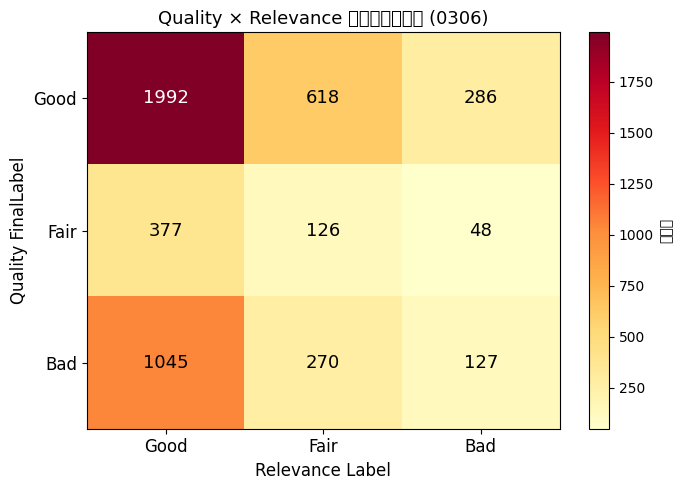

热力图已保存


In [39]:
import matplotlib.pyplot as plt
import numpy as np

# 热力图可视化
cross_plot = pd.crosstab(merged['FinalLabel'], merged['RelevanceLabel'])
# 确保行列顺序统一
order = ['Good', 'Fair', 'Bad']
cross_plot = cross_plot.reindex(index=[o for o in order if o in cross_plot.index],
                                 columns=[o for o in order if o in cross_plot.columns],
                                 fill_value=0)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cross_plot.values, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='图片数')
ax.set_xticks(range(len(cross_plot.columns)))
ax.set_yticks(range(len(cross_plot.index)))
ax.set_xticklabels(cross_plot.columns, fontsize=12)
ax.set_yticklabels(cross_plot.index, fontsize=12)
ax.set_xlabel('Relevance Label', fontsize=12)
ax.set_ylabel('Quality FinalLabel', fontsize=12)
ax.set_title('Quality × Relevance 交叉分布热力图 (0306)', fontsize=13)
for i in range(len(cross_plot.index)):
    for j in range(len(cross_plot.columns)):
        val = cross_plot.values[i, j]
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=13, color='black' if val < cross_plot.values.max()*0.6 else 'white')
plt.tight_layout()
Path(save_dir_base).mkdir(parents=True, exist_ok=True)
plt.savefig(os.path.join(save_dir_base, 'quality_x_relevance_heatmap_0306.png'), dpi=150, bbox_inches='tight')
plt.show()
print("热力图已保存")

In [40]:
# 关键子集统计
both_bad  = merged[(merged['FinalLabel'] == 'Bad')  & (merged['RelevanceLabel'] == 'Bad')]
q_bad_only = merged[(merged['FinalLabel'] == 'Bad')  & (merged['RelevanceLabel'] != 'Bad')]
r_bad_only = merged[(merged['FinalLabel'] != 'Bad')  & (merged['RelevanceLabel'] == 'Bad')]
both_good = merged[(merged['FinalLabel'] == 'Good') & (merged['RelevanceLabel'] == 'Good')]

print(f"Quality Bad  & Relevance Bad  : {len(both_bad):4d}  ({len(both_bad)/len(merged)*100:.1f}%)")
print(f"Quality Bad  only             : {len(q_bad_only):4d}  ({len(q_bad_only)/len(merged)*100:.1f}%)")
print(f"Relevance Bad only            : {len(r_bad_only):4d}  ({len(r_bad_only)/len(merged)*100:.1f}%)")
print(f"Quality Good & Relevance Good : {len(both_good):4d}  ({len(both_good)/len(merged)*100:.1f}%)")

Quality Bad  & Relevance Bad  :  127  (2.5%)
Quality Bad  only             : 1346  (26.9%)
Relevance Bad only            :  335  (6.7%)
Quality Good & Relevance Good : 1992  (39.8%)


In [41]:
# 标注一致性分析：各图 3 个标注人之间的一致率
def agreement_rate(row, vote_col, total_col='n_judges'):
    """最大票数 / 总票数"""
    return row[vote_col] / row[total_col] if row[total_col] > 0 else 0

# Quality 一致性（以 FinalDecision 最多票的标签为准）
voted_q['max_votes'] = voted_q[['Bad_votes', 'Fair_votes', 'Good_votes']].max(axis=1)
voted_q['agreement'] = voted_q['max_votes'] / voted_q['n_judges']
print(f"Quality 标注一致率（均值）: {voted_q['agreement'].mean()*100:.1f}%")
print(f"Quality 标注一致率分布:")
print(voted_q['agreement'].value_counts(normalize=True).sort_index(ascending=False).head(5))

print()

# Relevance 一致性
voted_r['max_rel_votes'] = voted_r[['Rel_Bad_votes', 'Rel_Fair_votes', 'Rel_Good_votes']].max(axis=1)
voted_r['agreement'] = voted_r['max_rel_votes'] / voted_r['n_judges']
print(f"Relevance 标注一致率（均值）: {voted_r['agreement'].mean()*100:.1f}%")
print(f"Relevance 标注一致率分布:")
print(voted_r['agreement'].value_counts(normalize=True).sort_index(ascending=False).head(5))

Quality 标注一致率（均值）: 71.0%
Quality 标注一致率分布:
agreement
1.000000    0.2588
0.666667    0.6128
0.333333    0.1284
Name: proportion, dtype: float64

Relevance 标注一致率（均值）: 77.7%
Relevance 标注一致率分布:
agreement
1.000000    0.4314
0.666667    0.4770
0.333333    0.0838
0.000000    0.0078
Name: proportion, dtype: float64


---
## 5. 导出结果 CSV

In [42]:
Path(save_dir_base).mkdir(parents=True, exist_ok=True)

# 各自结果
voted_q.to_csv(os.path.join(save_dir_base, 'voted_quality_0306.csv'), index=False)
voted_r.to_csv(os.path.join(save_dir_base, 'voted_relevance_0306.csv'), index=False)

# 联合结果
merged.to_csv(os.path.join(save_dir_base, 'merged_quality_relevance_0306.csv'), index=False)

# Quality Bad 列表
bad_quality = voted_q[voted_q['FinalLabel'] == 'Bad']
bad_quality.to_csv(os.path.join(save_dir_base, 'quality_bad_0306.csv'), index=False)

# Relevance Bad 列表
bad_relevance = voted_r[voted_r['RelevanceLabel'] == 'Bad']
bad_relevance.to_csv(os.path.join(save_dir_base, 'relevance_bad_0306.csv'), index=False)

print(f"结果已导出至: {save_dir_base}")
print(f"  voted_quality_0306.csv         ({len(voted_q)} 条)")
print(f"  voted_relevance_0306.csv       ({len(voted_r)} 条)")
print(f"  merged_quality_relevance_0306.csv ({len(merged)} 条)")
print(f"  quality_bad_0306.csv           ({len(bad_quality)} 条)")
print(f"  relevance_bad_0306.csv         ({len(bad_relevance)} 条)")

结果已导出至: D:\Data\T2I\AutoGenValidation\label_results_0306
  voted_quality_0306.csv         (5000 条)
  voted_relevance_0306.csv       (5000 条)
  merged_quality_relevance_0306.csv (5000 条)
  quality_bad_0306.csv           (1473 条)
  relevance_bad_0306.csv         (462 条)


---
## 6. （可选）下载图片到本地

---
## 7. ID 维度分析：每个 LP ID 有多少个 Prompt 不是 Bad

每个 LP ID（1-1000）对应 Prompt1~5 共 5 张图，统计每个 ID 中有 5/4/3/2/1/0 个 Prompt **不是 Bad**（即 Good 或 Fair）的比例。
分别对 **Quality** 和 **Relevance** 独立统计。

> **注**：以 `!= Bad` 为通过标准（Quality 通过率 ~70.5%，Relevance 通过率 ~88.8%），分布向高分端偏移，从左到右（0→5）呈递增趋势。

---
## 8. Bad Crop 过滤后的通过率分析

使用 Bad Crop Score（threshold = 0.1）过滤图片：`score > 0.1` → Bad Crop → 移除。
分别统计过滤前后在 **Image Level** 和 **LP ID Level** 的通过率变化。

In [43]:
# ── 读取 Bad Crop Score ──────────────────────────────────────────
crop_score_file = r"D:\Data\T2I\AutoGenValidation\0306_random1K_bad_crop_score.txt"
BAD_CROP_THRESHOLD = 0.1

df_crop = pd.read_csv(crop_score_file, sep='\t', header=None, names=['ImgUrl', 'CropScore'])
df_crop['ImgUrl'] = df_crop['ImgUrl'].astype(str).str.strip()
df_crop['is_bad_crop'] = df_crop['CropScore'] > BAD_CROP_THRESHOLD

n_total_crop = len(df_crop)
n_bad_crop   = df_crop['is_bad_crop'].sum()
n_keep       = n_total_crop - n_bad_crop

print(f"Crop Score 文件: {n_total_crop} 张图")
print(f"  Bad Crop (score > {BAD_CROP_THRESHOLD}): {n_bad_crop}  ({n_bad_crop/n_total_crop*100:.1f}%)")
print(f"  保留 (score <= {BAD_CROP_THRESHOLD}):    {n_keep}  ({n_keep/n_total_crop*100:.1f}%)")
print()
print("CropScore 分布统计:")
print(df_crop['CropScore'].describe().round(4))

df_crop.head(5)

Crop Score 文件: 5000 张图
  Bad Crop (score > 0.1): 460  (9.2%)
  保留 (score <= 0.1):    4540  (90.8%)

CropScore 分布统计:
count    5000.0000
mean        0.0523
std         0.0954
min         0.0172
25%         0.0215
50%         0.0237
75%         0.0292
max         0.7212
Name: CropScore, dtype: float64


,ImgUrl,CropScore,is_bad_crop
0,https://unitorchazureblob.blob.core.windows.ne...,0.212646,True
1,https://unitorchazureblob.blob.core.windows.ne...,0.032043,False
2,https://unitorchazureblob.blob.core.windows.ne...,0.018234,False
3,https://unitorchazureblob.blob.core.windows.ne...,0.029984,False
4,https://unitorchazureblob.blob.core.windows.ne...,0.029770,False


In [44]:
# ── Image Level 过滤前后对比 ────────────────────────────────────
# 将 crop score 合并进 voted_q 和 voted_r
voted_q_crop = voted_q.merge(df_crop[['ImgUrl', 'CropScore', 'is_bad_crop']], on='ImgUrl', how='left')
voted_r_crop = voted_r.merge(df_crop[['ImgUrl', 'CropScore', 'is_bad_crop']], on='ImgUrl', how='left')

# 过滤：保留 is_bad_crop == False（score <= threshold）
voted_q_filtered = voted_q_crop[voted_q_crop['is_bad_crop'] == False].copy()
voted_r_filtered = voted_r_crop[voted_r_crop['is_bad_crop'] == False].copy()

# ── 统计函数 ────────────────────────────────────────────────────
def image_level_stats(df, label_col, label='', pass_cond=None):
    """
    统计 Image Level 的通过率。
    pass_cond: 可选的通过条件函数，默认用 != 'Bad'
    """
    n = len(df)
    if n == 0:
        print(f"{label}: 0 张图，无法统计")
        return
    if pass_cond is None:
        pass_mask = df[label_col] != 'Bad'
    else:
        pass_mask = pass_cond(df)

    n_pass = pass_mask.sum()
    n_bad_label = (df[label_col] == 'Bad').sum()
    n_fair = (df[label_col] == 'Fair').sum() if 'Fair' in df[label_col].values else 0
    n_good = (df[label_col] == 'Good').sum() if 'Good' in df[label_col].values else 0
    print(f"  {label:<35s}: {n:5d} 张  |  Good {n_good:4d} ({n_good/n*100:.1f}%)  "
          f"Fair {n_fair:4d} ({n_fair/n*100:.1f}%)  Bad {n_bad_label:4d} ({n_bad_label/n*100:.1f}%)  "
          f"| 通过率(!=Bad) {n_pass/n*100:.1f}%")

print("=" * 85)
print("=== Image Level 通过率对比（通过标准: != Bad）===")
print("=" * 85)
print()
print("── Quality ──")
image_level_stats(voted_q_crop[voted_q_crop['is_bad_crop'].notna()], 'FinalLabel', '过滤前 (全部 5000 张)')
image_level_stats(voted_q_filtered, 'FinalLabel', f'过滤后 (crop <= {BAD_CROP_THRESHOLD})')
print()
print("── Relevance ──")
image_level_stats(voted_r_crop[voted_r_crop['is_bad_crop'].notna()], 'RelevanceLabel', '过滤前 (全部 5000 张)')
image_level_stats(voted_r_filtered, 'RelevanceLabel', f'过滤后 (crop <= {BAD_CROP_THRESHOLD})')

=== Image Level 通过率对比（通过标准: != Bad）===

── Quality ──
  过滤前 (全部 5000 张)                    :  5000 张  |  Good 2952 (59.0%)  Fair  562 (11.2%)  Bad 1473 (29.5%)  | 通过率(!=Bad) 70.5%
  过滤后 (crop <= 0.1)                  :  4540 张  |  Good 2793 (61.5%)  Fair  483 (10.6%)  Bad 1252 (27.6%)  | 通过率(!=Bad) 72.4%

── Relevance ──
  过滤前 (全部 5000 张)                    :  5000 张  |  Good 3421 (68.4%)  Fair 1019 (20.4%)  Bad  462 (9.2%)  | 通过率(!=Bad) 90.8%
  过滤后 (crop <= 0.1)                  :  4540 张  |  Good 3070 (67.6%)  Fair  939 (20.7%)  Bad  438 (9.6%)  | 通过率(!=Bad) 90.4%


In [45]:
# ── LP ID Level 过滤前后对比 ──────────────────────────────────────
# 通过标准（ID level）：该 ID 在过滤后剩余的图中，至少有 1 张 != Bad
# 同时统计不同"至少k张通过"的比例

def lp_id_level_stats(voted_df_with_crop, label_col, label=''):
    """
    统计 LP ID Level 的通过率，区分过滤前/后。
    返回每个 lp_num_id 的统计行。
    """
    df = voted_df_with_crop.copy()
    df['lp_num_id'] = df['lp_id'].apply(extract_lp_id)
    df['is_pass'] = (df[label_col] != 'Bad').astype(int)
    df['is_kept'] = (df['is_bad_crop'] == False).astype(int)

    records = []
    for lp_id, grp in df.groupby('lp_num_id'):
        total_before = len(grp)
        kept = grp[grp['is_bad_crop'] == False]
        total_after  = len(kept)

        pass_before = grp['is_pass'].sum()          # 过滤前通过张数
        pass_after  = kept['is_pass'].sum() if total_after > 0 else 0  # 过滤后通过张数

        records.append({
            'lp_num_id':     lp_id,
            'total_before':  total_before,
            'total_after':   total_after,
            'pass_before':   pass_before,
            'pass_after':    pass_after,
            'removed':       total_before - total_after,
        })

    return pd.DataFrame(records)

q_lp_stats = lp_id_level_stats(voted_q_crop, 'FinalLabel',      'Quality')
r_lp_stats = lp_id_level_stats(voted_r_crop, 'RelevanceLabel',  'Relevance')

# ── 打印 LP ID Level 汇总 ──────────────────────────────────────
def print_lp_id_summary(lp_stats, label=''):
    n_ids = len(lp_stats)
    print(f"=== {label} — LP ID Level 过滤前后对比 ===")
    print(f"  总 LP ID 数: {n_ids}")
    print()

    # 过滤后图片数分布
    n_removed_all = (lp_stats['total_after'] == 0).sum()
    n_partial     = ((lp_stats['total_after'] > 0) & (lp_stats['total_after'] < 5)).sum()
    n_full        = (lp_stats['total_after'] == 5).sum()
    print(f"  过滤后图片数分布:")
    print(f"    全部移除 (0/5 剩余): {n_removed_all:4d}  ({n_removed_all/n_ids*100:.1f}%)")
    print(f"    部分移除 (1-4/5):    {n_partial:4d}  ({n_partial/n_ids*100:.1f}%)")
    print(f"    全部保留 (5/5):      {n_full:4d}  ({n_full/n_ids*100:.1f}%)")
    print()

    # 过滤前 vs 过滤后：LP ID 通过率（至少1张pass）
    before_pass_any = (lp_stats['pass_before'] >= 1).sum()
    after_pass_any  = (lp_stats[lp_stats['total_after'] > 0]['pass_after'] >= 1).sum()
    after_ids       = (lp_stats['total_after'] > 0).sum()

    print(f"  LP ID 通过率（至少1张 != Bad）:")
    print(f"    过滤前: {before_pass_any}/{n_ids}  ({before_pass_any/n_ids*100:.1f}%)")
    print(f"    过滤后: {after_pass_any}/{after_ids}  ({after_pass_any/after_ids*100:.1f}%)  "
          f"（分母为过滤后仍有图的 {after_ids} 个ID）")
    print()

    # 通过张数分布对比（≥k 张pass）
    print(f"  {'Pass 张数':>10}  {'过滤前 ID数':>12}  {'过滤前 %':>10}  {'过滤后 ID数':>12}  {'过滤后 %':>10}")
    print("  " + "-" * 60)
    for k in range(5, -1, -1):
        b_cnt = (lp_stats['pass_before'] == k).sum()
        # 过滤后只在有图的ID里统计
        a_subset = lp_stats[lp_stats['total_after'] > 0]
        a_cnt = (a_subset['pass_after'] == k).sum()
        a_n   = len(a_subset)
        print(f"  {k}/5 pass    {b_cnt:>8}  {b_cnt/n_ids*100:>9.1f}%  "
              f"{a_cnt:>8}  {a_cnt/a_n*100:>9.1f}%")
    print()

print_lp_id_summary(q_lp_stats, 'Quality')
print_lp_id_summary(r_lp_stats, 'Relevance')

=== Quality — LP ID Level 过滤前后对比 ===
  总 LP ID 数: 1000

  过滤后图片数分布:
    全部移除 (0/5 剩余):    1  (0.1%)
    部分移除 (1-4/5):     346  (34.6%)
    全部保留 (5/5):       653  (65.3%)

  LP ID 通过率（至少1张 != Bad）:
    过滤前: 995/1000  (99.5%)
    过滤后: 985/999  (98.6%)  （分母为过滤后仍有图的 999 个ID）

     Pass 张数       过滤前 ID数       过滤前 %       过滤后 ID数       过滤后 %
  ------------------------------------------------------------
  5/5 pass         208       20.8%       151       15.1%
  4/5 pass         334       33.4%       302       30.2%
  3/5 pass         292       29.2%       321       32.1%
  2/5 pass         114       11.4%       151       15.1%
  1/5 pass          47        4.7%        60        6.0%
  0/5 pass           5        0.5%        14        1.4%

=== Relevance — LP ID Level 过滤前后对比 ===
  总 LP ID 数: 1000

  过滤后图片数分布:
    全部移除 (0/5 剩余):    1  (0.1%)
    部分移除 (1-4/5):     346  (34.6%)
    全部保留 (5/5):       653  (65.3%)

  LP ID 通过率（至少1张 != Bad）:
    过滤前: 999/1000  (99.9%)
    过滤后: 996/999  (99.7%)  （分母

C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\2027704854.py:69: UserWarning: Glyph 21344 (\N{CJK UNIFIED IDEOGRAPH-5360}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\2027704854.py:69: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\2027704854.py:69: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\2027704854.py:69: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\2027704854.py:69: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinjinchen\AppData\Local\Temp\ipykernel_474860\202770485

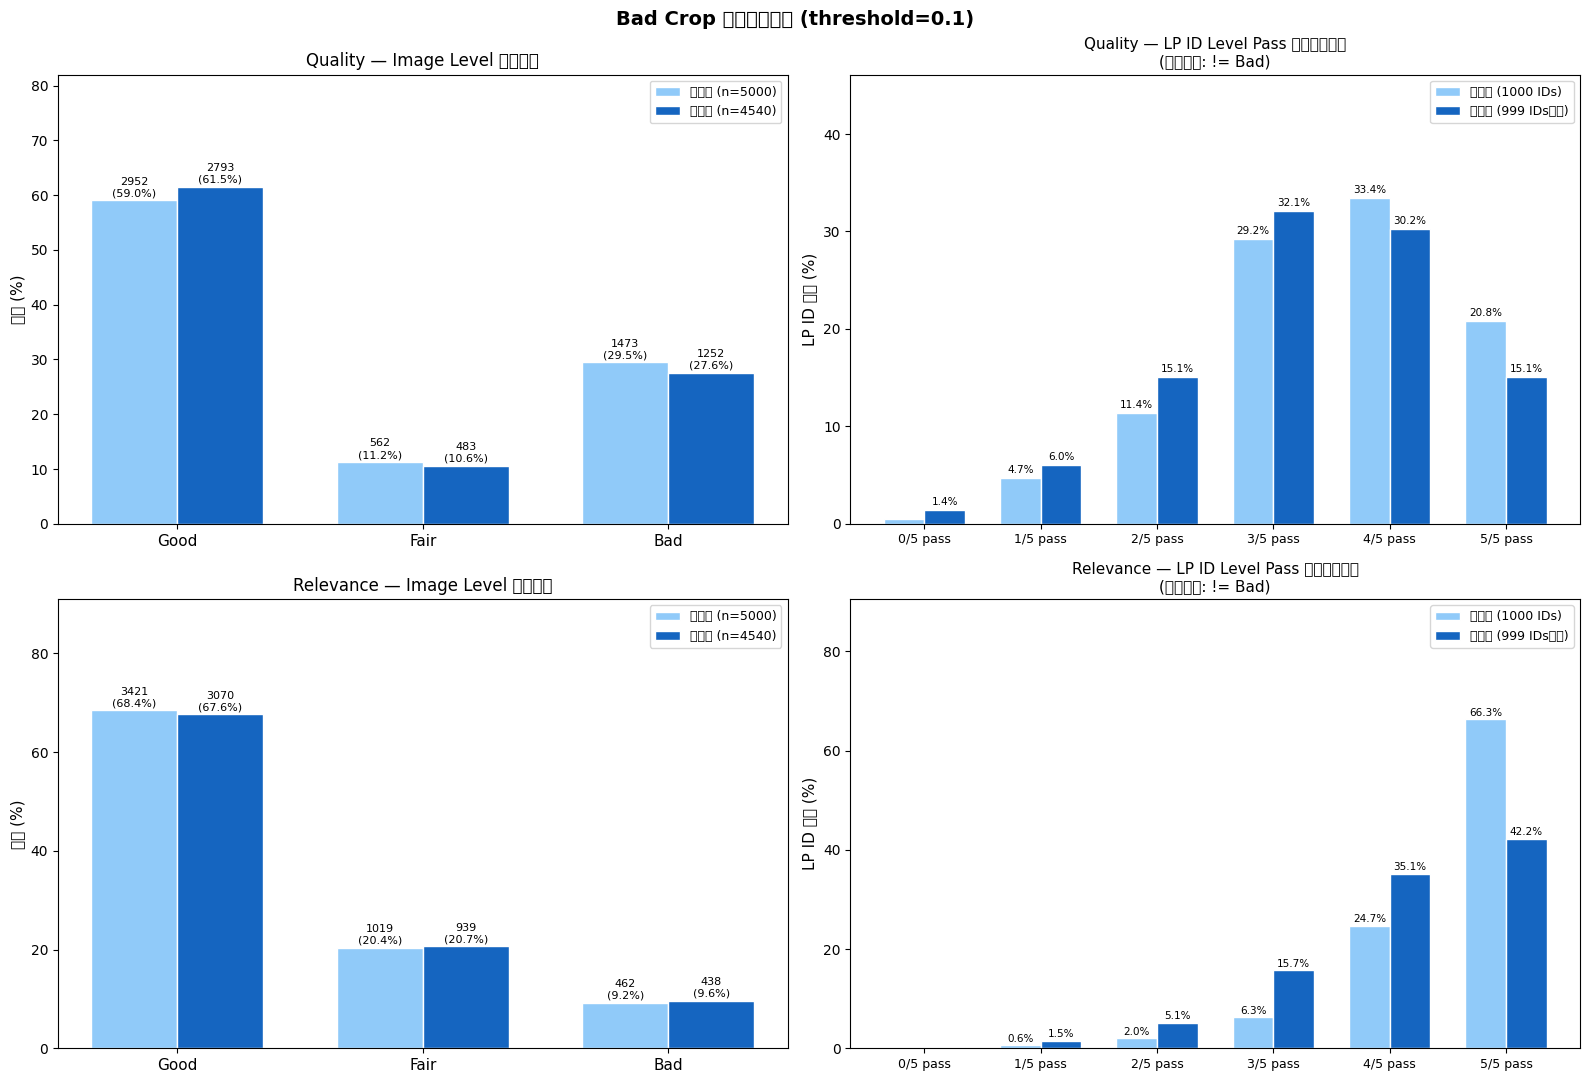

图表已保存


In [46]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(f'Bad Crop 过滤前后对比 (threshold={BAD_CROP_THRESHOLD})', fontsize=14, fontweight='bold')

palette_before = '#90CAF9'   # 浅蓝
palette_after  = '#1565C0'   # 深蓝

for row, (lp_stats, voted_crop, label_col, title_prefix) in enumerate([
    (q_lp_stats, voted_q_crop, 'FinalLabel',     'Quality'),
    (r_lp_stats, voted_r_crop, 'RelevanceLabel', 'Relevance'),
]):
    n_ids    = len(lp_stats)
    a_subset = lp_stats[lp_stats['total_after'] > 0]
    a_n      = len(a_subset)

    # ── 左图：Image Level Good/Fair/Bad 对比 ──────────────────
    ax = axes[row][0]
    categories = ['Good', 'Fair', 'Bad']
    before_cnts = [
        (voted_crop[label_col] == c).sum() for c in categories
    ]
    after_cnts = [
        (voted_crop[(voted_crop['is_bad_crop'] == False)][label_col] == c).sum()
        for c in categories
    ]
    n_before = len(voted_crop)
    n_after  = (voted_crop['is_bad_crop'] == False).sum()

    x = np.arange(len(categories))
    w = 0.35
    b1 = ax.bar(x - w/2, [c/n_before*100 for c in before_cnts], w,
                label=f'过滤前 (n={n_before})', color=palette_before, edgecolor='white')
    b2 = ax.bar(x + w/2, [c/n_after*100  for c in after_cnts],  w,
                label=f'过滤后 (n={n_after})',  color=palette_after,  edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylabel('占比 (%)', fontsize=11)
    ax.set_title(f'{title_prefix} — Image Level 分布对比', fontsize=12)
    ax.legend(fontsize=9)
    ax.set_ylim(0, max(max([c/n_before*100 for c in before_cnts]),
                       max([c/n_after*100  for c in after_cnts])) * 1.3 + 2)
    for bar, cnt, n in [(b1, before_cnts, n_before), (b2, after_cnts, n_after)]:
        for b, c in zip(bar, cnt):
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.4,
                    f'{c}\n({c/n*100:.1f}%)', ha='center', va='bottom', fontsize=8)

    # ── 右图：LP ID Level pass_count 分布对比（柱图）──────────
    ax = axes[row][1]
    before_pcts = [(lp_stats['pass_before'] == k).sum() / n_ids * 100  for k in range(6)]
    after_pcts  = [(a_subset['pass_after']  == k).sum() / a_n   * 100  for k in range(6)]

    x = np.arange(6)
    b1 = ax.bar(x - w/2, before_pcts, w, label=f'过滤前 ({n_ids} IDs)',  color=palette_before, edgecolor='white')
    b2 = ax.bar(x + w/2, after_pcts,  w, label=f'过滤后 ({a_n} IDs有图)', color=palette_after,  edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{k}/5 pass' for k in range(6)], fontsize=9)
    ax.set_ylabel('LP ID 占比 (%)', fontsize=11)
    ax.set_title(f'{title_prefix} — LP ID Level Pass 数量分布对比\n(通过标准: != Bad)', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylim(0, max(max(before_pcts), max(after_pcts)) * 1.35 + 1)
    for bar, pcts in [(b1, before_pcts), (b2, after_pcts)]:
        for b, p in zip(bar, pcts):
            if p > 0.5:
                ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                        f'{p:.1f}%', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig(os.path.join(save_dir_base, 'bad_crop_filter_comparison_0306.png'), dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存")

In [47]:
# ── 汇总表：Image Level + LP ID Level 过滤前后对比 ──────────────
rows = []
for lp_stats, voted_crop, label_col, task in [
    (q_lp_stats, voted_q_crop, 'FinalLabel',     'Quality'),
    (r_lp_stats, voted_r_crop, 'RelevanceLabel', 'Relevance'),
]:
    n_img_before  = len(voted_crop)
    n_img_after   = (voted_crop['is_bad_crop'] == False).sum()
    pass_img_before = (voted_crop[label_col] != 'Bad').sum()
    pass_img_after  = ((voted_crop['is_bad_crop'] == False) & (voted_crop[label_col] != 'Bad')).sum()

    n_ids         = len(lp_stats)
    a_subset      = lp_stats[lp_stats['total_after'] > 0]
    a_n           = len(a_subset)
    pass_id_before = (lp_stats['pass_before'] >= 1).sum()
    pass_id_after  = (a_subset['pass_after'] >= 1).sum()

    rows.append({
        'Task': task, 'Level': 'Image',
        '过滤前总数': n_img_before, '过滤后总数': n_img_after,
        '被移除': n_img_before - n_img_after,
        '过滤前通过数': pass_img_before, '过滤前通过率': f'{pass_img_before/n_img_before*100:.1f}%',
        '过滤后通过数': pass_img_after,  '过滤后通过率': f'{pass_img_after/n_img_after*100:.1f}%',
    })
    rows.append({
        'Task': task, 'Level': 'LP ID (≥1 pass)',
        '过滤前总数': n_ids, '过滤后总数': a_n,
        '被移除': n_ids - a_n,
        '过滤前通过数': pass_id_before, '过滤前通过率': f'{pass_id_before/n_ids*100:.1f}%',
        '过滤后通过数': pass_id_after,  '过滤后通过率': f'{pass_id_after/a_n*100:.1f}%',
    })

result_df = pd.DataFrame(rows)
print("=== Bad Crop 过滤前后汇总（通过标准: != Bad）===")
print(result_df.to_string(index=False))

result_df.to_csv(os.path.join(save_dir_base, 'bad_crop_filter_summary_0306.csv'), index=False)
print(f"\n汇总表已保存至: {save_dir_base}/bad_crop_filter_summary_0306.csv")

=== Bad Crop 过滤前后汇总（通过标准: != Bad）===
     Task           Level  过滤前总数  过滤后总数  被移除  过滤前通过数 过滤前通过率  过滤后通过数 过滤后通过率
  Quality           Image   5000   4540  460    3527  70.5%    3288  72.4%
  Quality LP ID (≥1 pass)   1000    999    1     995  99.5%     985  98.6%
Relevance           Image   5000   4540  460    4538  90.8%    4102  90.4%
Relevance LP ID (≥1 pass)   1000    999    1     999  99.9%     996  99.7%

汇总表已保存至: D:\Data\T2I\AutoGenValidation\label_results_0306/bad_crop_filter_summary_0306.csv


In [48]:
import re

def extract_lp_id(lp_id_str):
    """从 lp_id 中提取数字 ID，如 'Random1000_676_Prompt5_1344x768.jpg' → 676"""
    m = re.search(r'Random1000_(\d+)_Prompt', str(lp_id_str))
    return int(m.group(1)) if m else None

# ---- Quality：每个 ID 的"不是 Bad"数量 ----
# 通过标准：FinalLabel != 'Bad'（即 Good 或 Fair 均算通过）
voted_q['lp_num_id'] = voted_q['lp_id'].apply(extract_lp_id)
voted_q['is_pass_q'] = (voted_q['FinalLabel'] != 'Bad').astype(int)

q_id_stats = voted_q.groupby('lp_num_id').agg(
    total_prompts=('lp_id', 'count'),
    pass_count=('is_pass_q', 'sum')
).reset_index()
q_id_stats.rename(columns={'pass_count': 'good_count'}, inplace=True)

# ---- Relevance：每个 ID 的"不是 Bad"数量 ----
voted_r['lp_num_id'] = voted_r['lp_id'].apply(extract_lp_id)
voted_r['is_pass_r'] = (voted_r['RelevanceLabel'] != 'Bad').astype(int)

r_id_stats = voted_r.groupby('lp_num_id').agg(
    total_prompts=('lp_id', 'count'),
    pass_count=('is_pass_r', 'sum')
).reset_index()
r_id_stats.rename(columns={'pass_count': 'good_count'}, inplace=True)

print(f"Quality  - 共 {len(q_id_stats)} 个 LP ID  (通过标准: != Bad)")
print(f"Relevance - 共 {len(r_id_stats)} 个 LP ID  (通过标准: != Bad)")
print()
print("Quality pass_count 分布（每个ID有几个Prompt不是Bad）:")
print(q_id_stats['good_count'].value_counts().sort_index())
print()
print("Relevance pass_count 分布:")
print(r_id_stats['good_count'].value_counts().sort_index())

Quality  - 共 1000 个 LP ID  (通过标准: != Bad)
Relevance - 共 1000 个 LP ID  (通过标准: != Bad)

Quality pass_count 分布（每个ID有几个Prompt不是Bad）:
good_count
0      5
1     47
2    114
3    292
4    334
5    208
Name: count, dtype: int64

Relevance pass_count 分布:
good_count
0      1
1      6
2     20
3     63
4    247
5    663
Name: count, dtype: int64


In [49]:
def prompt_good_distribution(id_stats, label='', pass_label='!= Bad'):
    """打印每个 ID 中 0~5 个 Prompt 通过的数量及比例"""
    n_ids = len(id_stats)
    print(f"=== {label} — 每个 LP ID 中通过（{pass_label}）的 Prompt 数量分布 ===")
    print(f"{'Pass Prompts':>14}  {'ID 数量':>8}  {'占比':>8}  {'累计（≥N个Pass）':>18}")
    print("-" * 58)
    cumulative = 0
    # 从高到低打印便于阅读
    for k in range(5, -1, -1):
        cnt = (id_stats['good_count'] == k).sum()
        pct = cnt / n_ids * 100
        cumulative += cnt
        cum_pct = cumulative / n_ids * 100
        bar = '█' * int(pct / 2)
        print(f"  {k}/5 pass    {cnt:>6}    {pct:>6.1f}%    ≥{k}: {cumulative:>5} ({cum_pct:.1f}%)  {bar}")
    print(f"  Total IDs: {n_ids}")
    print()

prompt_good_distribution(q_id_stats, 'Quality')
prompt_good_distribution(r_id_stats, 'Relevance')

=== Quality — 每个 LP ID 中通过（!= Bad）的 Prompt 数量分布 ===
  Pass Prompts     ID 数量        占比         累计（≥N个Pass）
----------------------------------------------------------
  5/5 pass       208      20.8%    ≥5:   208 (20.8%)  ██████████
  4/5 pass       334      33.4%    ≥4:   542 (54.2%)  ████████████████
  3/5 pass       292      29.2%    ≥3:   834 (83.4%)  ██████████████
  2/5 pass       114      11.4%    ≥2:   948 (94.8%)  █████
  1/5 pass        47       4.7%    ≥1:   995 (99.5%)  ██
  0/5 pass         5       0.5%    ≥0:  1000 (100.0%)  
  Total IDs: 1000

=== Relevance — 每个 LP ID 中通过（!= Bad）的 Prompt 数量分布 ===
  Pass Prompts     ID 数量        占比         累计（≥N个Pass）
----------------------------------------------------------
  5/5 pass       663      66.3%    ≥5:   663 (66.3%)  █████████████████████████████████
  4/5 pass       247      24.7%    ≥4:   910 (91.0%)  ████████████
  3/5 pass        63       6.3%    ≥3:   973 (97.3%)  ███
  2/5 pass        20       2.0%    ≥2:   993 (99.3%)  █


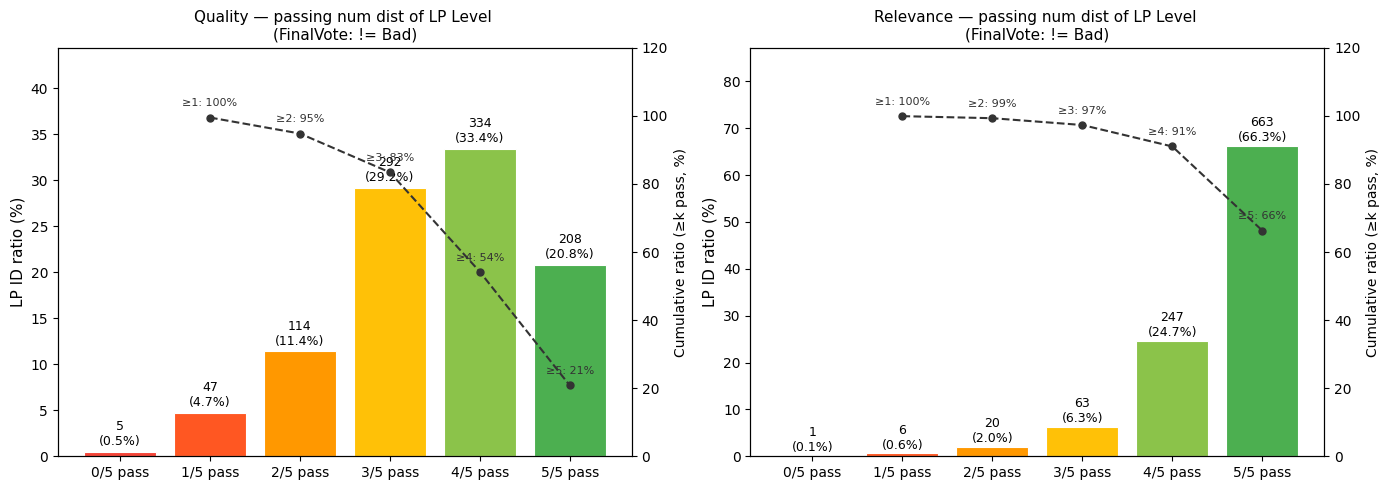

图表已保存


In [54]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, id_stats, title in [
    (axes[0], q_id_stats,  'Quality — passing num dist of LP Level \n(FinalVote: != Bad)'),
    (axes[1], r_id_stats,  'Relevance — passing num dist of LP Level \n(FinalVote: != Bad)'),
]:
    n_ids = len(id_stats)
    counts = [(id_stats['good_count'] == k).sum() for k in range(6)]
    pcts   = [c / n_ids * 100 for c in counts]

    # 渐变色：通过数越多越绿（0→5 从红到绿，与 X 轴递增对应）
    palette = ['#F44336', '#FF5722', '#FF9800', '#FFC107', '#8BC34A', '#4CAF50']
    bars = ax.bar(range(6), pcts, color=palette, edgecolor='white', linewidth=0.8)
    ax.set_xticks(range(6))
    ax.set_xticklabels([f'{k}/5 pass' for k in range(6)], fontsize=10)
    ax.set_ylabel('LP ID ratio (%)', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, max(pcts) * 1.3 + 1)

    for bar, cnt, pct in zip(bars, counts, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{cnt}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

    # 累计折线右轴：≥1 ~ ≥5，去掉无意义的 ≥0=100%
    # cum_pcts[k] = P(good_count >= k+1), x 位置对齐柱子 1~5
    cum_pcts = [
        (id_stats['good_count'] >= k).sum() / n_ids * 100
        for k in range(1, 6)
    ]
    ax2 = ax.twinx()
    ax2.plot(range(1, 6), cum_pcts, 'o--', color='#333', linewidth=1.5, markersize=5)
    ax2.set_ylabel('Cumulative ratio (≥k pass, %)', fontsize=10)
    ax2.set_ylim(0, 120)
    for x, y in zip(range(1, 6), cum_pcts):
        ax2.annotate(f'≥{x}: {y:.0f}%', (x, y), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8, color='#333')

plt.tight_layout()
Path(save_dir_base).mkdir(parents=True, exist_ok=True)
plt.savefig(os.path.join(save_dir_base, 'prompt_pass_distribution_0306.png'), dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存")

In [51]:
# Quality 和 Relevance 并排对比汇总表（通过标准: != Bad）
summary_rows = []
n_q = len(q_id_stats)
n_r = len(r_id_stats)
for k in range(5, -1, -1):
    q_cnt = (q_id_stats['good_count'] == k).sum()
    r_cnt = (r_id_stats['good_count'] == k).sum()
    summary_rows.append({
        'Pass Prompts (out of 5)': f'{k}/5',
        'Quality IDs':   q_cnt,
        'Quality %':     f'{q_cnt/n_q*100:.1f}%',
        'Relevance IDs': r_cnt,
        'Relevance %':   f'{r_cnt/n_r*100:.1f}%',
    })

summary_df = pd.DataFrame(summary_rows)
print("=== Quality vs Relevance：每个 LP ID 的通过（!= Bad）Prompt 数量对比 ===")
print(summary_df.to_string(index=False))

summary_df.to_csv(os.path.join(save_dir_base, 'prompt_pass_summary_0306.csv'), index=False)
print(f"\n对比表已保存至: {save_dir_base}/prompt_pass_summary_0306.csv")

=== Quality vs Relevance：每个 LP ID 的通过（!= Bad）Prompt 数量对比 ===
Pass Prompts (out of 5)  Quality IDs Quality %  Relevance IDs Relevance %
                    5/5          208     20.8%            663       66.3%
                    4/5          334     33.4%            247       24.7%
                    3/5          292     29.2%             63        6.3%
                    2/5          114     11.4%             20        2.0%
                    1/5           47      4.7%              6        0.6%
                    0/5            5      0.5%              1        0.1%

对比表已保存至: D:\Data\T2I\AutoGenValidation\label_results_0306/prompt_pass_summary_0306.csv


In [53]:
# ── 下载配置 ─────────────────────────────────────────────────────
BAD_REASON_THRESHOLD = 2   # 维度 Bad 票数 >= 2 才算该维度的 confirmed bad reason

# Bad Reason 维度顺序（不放回过滤，优先级从上到下）
bad_reason_order = [
    'TextLogoClarity',
    'RealisticPhysicallyPlausible',
    'BrightnessContrastColorSaturation',
    'Imageclarity',
    'SubjectClarity',
    'CompositionLayout',
]

# ── 1. Relevance Bad → 单文件夹 ──────────────────────────────────
print("=" * 60)
print("下载 Relevance Bad 图片...")
bad_rel_urls = voted_r[voted_r['RelevanceLabel'] == 'Bad']['ImgUrl'].tolist()
download_images(
    bad_rel_urls,
    os.path.join(save_dir_base, 'relevance_bad'),
    label='Relevance-Bad'
)

# ── 2. Quality Bad → 按 Bad Reason 分子文件夹（不放回） ──────────
print()
print("=" * 60)
print("下载 Quality Bad 图片（按 Bad Reason 分子文件夹）...")

bad_q_df = voted_q[voted_q['FinalLabel'] == 'Bad'].copy()

# 分配每张图的子文件夹（不放回：按维度顺序，命中第一个即停）
def assign_bad_reason(row, dims, threshold):
    """
    按 dims 顺序查找第一个 bad_votes >= threshold 的维度。
    若均不满足 → 'Inconsistent reasons'
    """
    for dim in dims:
        col = f'{dim}_bad_votes'
        if col in row.index and row[col] >= threshold:
            return dim
    return 'Inconsistent reasons'

bad_q_df['bad_reason'] = bad_q_df.apply(
    assign_bad_reason, axis=1, dims=bad_reason_order, threshold=BAD_REASON_THRESHOLD
)

# 统计各子文件夹数量
reason_counts = bad_q_df['bad_reason'].value_counts()
print(f"\nQuality Bad 共 {len(bad_q_df)} 张，按 Bad Reason 分配（Bad 票 ≥ {BAD_REASON_THRESHOLD}）：")
for reason in bad_reason_order + ['Inconsistent reasons']:
    cnt = reason_counts.get(reason, 0)
    print(f"  {reason:<45s}: {cnt:4d} 张")

# 下载各子文件夹
print()
for reason in bad_reason_order + ['Inconsistent reasons']:
    subset = bad_q_df[bad_q_df['bad_reason'] == reason]
    if len(subset) == 0:
        continue
    sub_dir = os.path.join(save_dir_base, 'quality_bad', reason)
    download_images(subset['ImgUrl'].tolist(), sub_dir, label=reason)

# ── 打印目录结构 ─────────────────────────────────────────────────
print()
print("=" * 60)
print("下载完成！目录结构：")
print(f"  {save_dir_base}/")
print(f"  ├── relevance_bad/                         ← Relevance Bad ({len(bad_rel_urls)} 张)")
print(f"  └── quality_bad/")
for reason in bad_reason_order + ['Inconsistent reasons']:
    cnt = reason_counts.get(reason, 0)
    if cnt > 0:
        print(f"      ├── {reason}/  ({cnt} 张)")

下载 Relevance Bad 图片...
  [Relevance-Bad] 成功: 462, 失败: 0, 目录: D:\Data\T2I\AutoGenValidation\label_results_0306\relevance_bad

下载 Quality Bad 图片（按 Bad Reason 分子文件夹）...

Quality Bad 共 1473 张，按 Bad Reason 分配（Bad 票 ≥ 2）：
  TextLogoClarity                              :   60 张
  RealisticPhysicallyPlausible                 :  804 张
  BrightnessContrastColorSaturation            :    0 张
  Imageclarity                                 :    3 张
  SubjectClarity                               :  132 张
  CompositionLayout                            :   23 张
  Inconsistent reasons                         :  451 张

  [TextLogoClarity] 成功: 60, 失败: 0, 目录: D:\Data\T2I\AutoGenValidation\label_results_0306\quality_bad\TextLogoClarity
  [RealisticPhysicallyPlausible] 成功: 804, 失败: 0, 目录: D:\Data\T2I\AutoGenValidation\label_results_0306\quality_bad\RealisticPhysicallyPlausible
  [Imageclarity] 成功: 3, 失败: 0, 目录: D:\Data\T2I\AutoGenValidation\label_results_0306\quality_bad\Imageclarity
  [SubjectClarity] 成功: 